In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags as sparMtrx

In [2]:
N = 11
xf = 2*np.pi

x = np.linspace(0,xf, N)
h = np.diff(x)[0]
h

np.float64(0.6283185307179586)

## Left and Right Stencil
Note, I am defining an array of the coefficients and neglecting the propper positions since they will be placed at various locations. I will place them in the proper collomum when the matrix is defined

Left Boundary

`ld1:`
$$f'_j = \frac{-3f_j + 4f_{j+1} - f_{j+2}}{2\Delta}\to\frac{1}{2\Delta}\begin{bmatrix}-3&4&-1\end{bmatrix}\begin{bmatrix}f_j\\ f_{j+1}\\ f_{j+2}\end{bmatrix}$$

`ld2:`
$$f''_j = \frac{2f_j - 5f_{j+1} + 4f_{j+2} - f_{j+3}}{\Delta^2}\to\frac{1}{\Delta^2}\begin{bmatrix}2&-5&4&-1\end{bmatrix}\begin{bmatrix}f_j\\ f_{j+1}\\ f_{j+2}\\ f_{j+3}\end{bmatrix}$$

In [3]:
def ld1(h):
    return np.array([-3,4,-1])/(2*h)
def ld2(h):
    return np.array([2,-5,4,-1])/(h**2)

Right Boundary

`rd1:`
$$f'_j = \frac{f_{j-2}-4f_{j-1}+3f_{j}}{2\Delta}\to\frac{1}{2\Delta}\begin{bmatrix}1&-4&3\end{bmatrix}\begin{bmatrix}f_{j-2}\\ f_{j-1}\\ f_{j}\end{bmatrix}$$

`rd2:`
$$f''_j = \frac{-f_{j-3}+4f_{j-2}-5f_{j-1}+2f_{j}}{\Delta^2}\to\frac{1}{\Delta^2}\begin{bmatrix}-1&4&-5&2\end{bmatrix}\begin{bmatrix}f_{j-3}\\ f_{j-2}\\ f_{j-1}\\ f_{j}\end{bmatrix}$$

In [4]:
def rd1(h):
    return np.array([1,-4,3])/(2*h)
def rd2(h):
    return np.array([-1,4,-5,2])/(h**2)

## Generating Matricies

First derivative, Second order accurate `D2`, with main diagonal, central stencil, `m2d1:`
$$\frac{1}{2\Delta}\begin{bmatrix}-1&1\end{bmatrix}\begin{bmatrix}f_{j-1}\\ f_{j+1}\end{bmatrix}$$

In [5]:
# First define the matrix with the central stenicl along the entire diagonal
m2d1 = np.array([-1,1])/(2*h)

D2 = sparMtrx(m2d1,
              [-1, 1],
              shape=(x.size, x.size)).toarray()

# Clear the first and last row
D2[0] = np.zeros(x.size)
D2[-1] = np.zeros(x.size)

# Place the boundary stencil in the first and last row
D2[0,:3] = ld1(h)
D2[-1,-3:] = rd1(h)


#Plotting the upper-left corner of the matrix
np.round(D2[:4,:4],2)

array([[-2.39,  3.18, -0.8 ,  0.  ],
       [-0.8 ,  0.  ,  0.8 ,  0.  ],
       [ 0.  , -0.8 ,  0.  ,  0.8 ],
       [ 0.  ,  0.  , -0.8 ,  0.  ]])

First derivative, Fourth order accurate `D4`, with main diagonal, central stencil, `m4d1:`
$$\frac{1}{12\Delta}\begin{bmatrix}1&-8&8&-1\end{bmatrix}\begin{bmatrix}f_{j-2}\\ f_{j-1}\\ f_{j+1}\\ f_{j+2}\end{bmatrix}$$

In [6]:
# First define the matrix with the central stenicl along the entire diagonal
m4d1 = np.array([1,-8,8,-1])/(12*h)

D4 = sparMtrx(m4d1,
              [-2, -1,  1, 2],
              shape=(x.size, x.size)).toarray()

# Clear the first two rows, and the last two rows
D4[0] = np.zeros(x.size)
D4[1] = np.zeros(x.size)
D4[-2] = np.zeros(x.size)
D4[-1] = np.zeros(x.size)

# Place the boundary stencil in the first two rows and last two rows
D4[0,:3] = ld1(h)
D4[1,1:4] = ld1(h)
D4[-2,-4:-1] = rd1(h)
D4[-1,-3:] = rd1(h)

#Plotting the upper-left corner of the matrix
np.round(D4[:4,:4],2)

array([[-2.39,  3.18, -0.8 ,  0.  ],
       [ 0.  , -2.39,  3.18, -0.8 ],
       [ 0.13, -1.06,  0.  ,  1.06],
       [ 0.  ,  0.13, -1.06,  0.  ]])

Second derivative, Second order accurate `L2`, with main diagonal, central stencil, `m2d2:`
$$\frac{1}{\Delta^2}\begin{bmatrix}1&-2&1\end{bmatrix}\begin{bmatrix}f_{j-1}\\f_j\\ f_{j+1}\end{bmatrix}$$

In [7]:
# First define the matrix with the central stenicl along the entire diagonal
m2d2 = np.array([1,-2,1])/(h**2)

L2 = sparMtrx(m2d2,
              [-1, 0, 1],
              shape=(x.size, x.size)).toarray()

# Clear the first row, and the last row
L2[0] = np.zeros(x.size)
L2[-1] = np.zeros(x.size)


# Place the boundary stencil in the first row, and last row
L2[0,:4] = ld2(h)
L2[-1,-4:] = rd2(h)


#Plotting the upper-left corner of the matrix
np.round(L2[:4,:4],2)

array([[  5.07, -12.67,  10.13,  -2.53],
       [  2.53,  -5.07,   2.53,   0.  ],
       [  0.  ,   2.53,  -5.07,   2.53],
       [  0.  ,   0.  ,   2.53,  -5.07]])

In [8]:
m4d2 = np.array([-1,16,-30,16,-1])/(12*h**2)

L4 = sparMtrx(m4d2,
              [-2, -1, 0, 1, 2],
              shape=(x.size, x.size)).toarray()

# Clear the first two rows, and the last two rows
L4[0] = np.zeros(x.size)
L4[1] = np.zeros(x.size)
L4[-2] = np.zeros(x.size)
L4[-1] = np.zeros(x.size)


# Place the boundary stencil in the first two rows and last two rows
L4[0,:4] = ld2(h)
L4[1,1:5] = ld2(h)
L4[-2,-5:-1] = rd2(h)
L4[-1,-4:] = rd2(h)


#Plotting the upper-left corner of the matrix
np.round(L4[:4,:4],2)

array([[  5.07, -12.67,  10.13,  -2.53],
       [  0.  ,   5.07, -12.67,  10.13],
       [ -0.21,   3.38,  -6.33,   3.38],
       [  0.  ,  -0.21,   3.38,  -6.33]])

## Calculating and Plotting

In [9]:
y = np.sin(x)
dy_exact = np.cos(x)

dy_o2 = D2@y
dy_o4 = D4@y

In [10]:
d2y_exact = -np.sin(x)

d2y_o2 = L2@y
d2y_o4 = L4@y

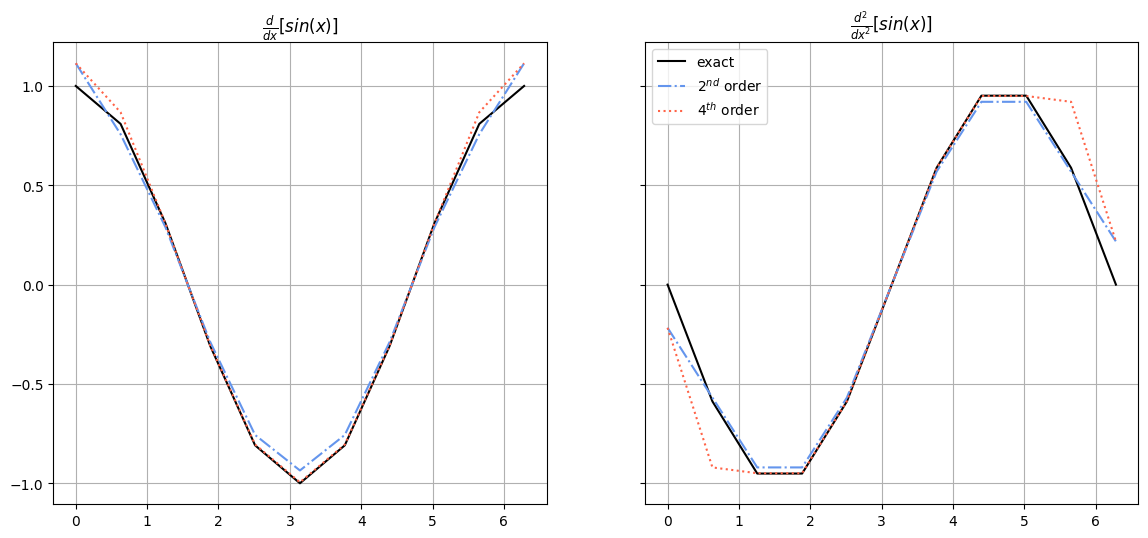

In [11]:
fig, (p1,p2) = plt.subplots(1,2,figsize=(14,6),sharey=True)

p1.plot(x,dy_exact,color='black',label='exact')
p1.plot(x,dy_o2, color='cornflowerblue',label=r'$2^{nd}$ order',linestyle='-.')
p1.plot(x,dy_o4,color='tomato',label=r'$4^{th}$ order',linestyle=':')

p1.set_title(r'$\frac{d}{dx}[sin(x)]$')
p1.grid()

p2.plot(x,d2y_exact,color='black',label='exact')
p2.plot(x,d2y_o2, color='cornflowerblue',label=r'$2^{nd}$ order',linestyle='-.')
p2.plot(x,d2y_o4,color='tomato',label=r'$4^{th}$ order',linestyle=':')

p2.set_title(r'$\frac{d^2}{dx^2}[sin(x)]$')
p2.grid()
p2.legend()

plt.show()

# Problem 2

$$\frac{\partial C}{\partial t} = D \frac{\partial^2 C}{\partial x^2} - u \frac{\partial C}{\partial x} $$

Exact solution
$$c(x,t) = \int_{-\infty}^{\infty}\frac{f(\hat x)}{\sqrt{4\pi Dt}}e^{-\frac{(x-\hat x-Ut)^2}{4Dt}}d\hat x$$

For $c(x,0) = Asin(kx)$
$$c(x,t) = Ae^{-Dk^2t}sin(k(x-ut))$$


## Define Functions

The functions from above needs to be re-written with new conditions for the boundary. In **Problem 1** we used *boundary stencils*, but here they need to be periodic. I found that both the left and right end need to have periodic conditions to give good results. My implimentation amounts to using the appropriate *center stencil*, and looping through the array indicies as follows

`D4`, far left boundary (first array element)
$$f'_0 = \frac{1}{12\Delta}\begin{bmatrix}1&-8&8&-1\end{bmatrix}\begin{bmatrix}f_{-2}\\ f_{-1}\\ f_{1}\\ f_{2}\end{bmatrix}$$


`D4`, far right boundary (last array element)
$$f'_{-1} = \frac{1}{12\Delta}\begin{bmatrix}1&-8&8&-1\end{bmatrix}\begin{bmatrix}f_{-3}\\ f_{-3}\\ f_{0}\\ f_{1}\end{bmatrix}$$

In [12]:
def D2_make(n,h):
    # First define the matrix with the central stenicl along the entire diagonal
    m2d1 = np.array([-1,1])/(2*h)
    
    M = sparMtrx(m2d1,
                  [-1, 1],
                  shape=(n, n)).toarray()
    
    # Clear the first and last row
    M[0] = np.zeros(n)
    M[-1] = np.zeros(n)
    
    # Place the boundary stencil in the first and last row
    # M[0,:3] = ld1(h)
    # M[-1,-3:] = rd1(h)

    # Periodic Stencil
    M[0,-1] = -1/(2*h)
    M[0,1] = 1/(2*h)
    
    return M

In [13]:
def L2_make(n,h):
    # First define the matrix with the central stenicl along the entire diagonal
    m2d2 = np.array([1,-2,1])/(h**2)
    
    M = sparMtrx(m2d2,
                  [-1, 0, 1],
                  shape=(n, n)).toarray()
    
    # Clear the first row, and the last row
    M[0] = np.zeros(n)
    M[-1] = np.zeros(n)
    
    
    # Place the boundary stencil in the first row, and last row
    # M[0,:4] = ld2(h)
    # M[-1,-4:] = rd2(h)

    # Periodic Stincel
    M[0,-1] = 1/(h**2)
    M[0,0] = -2/(h**2)
    M[0,1] = 1/(h**2)
    
    M[-1,-2] = 1/(h**2)
    M[-1,-1] = -2/(h**2)
    M[-1,0] = 1/(h**2)
    
    return M

In [14]:
def L4_make(n,h):
    m4d2 = np.array([-1,16,-30,16,-1])/(12*h**2)

    M = sparMtrx(m4d2,
                  [-2, -1, 0, 1, 2],
                  shape=(n, n)).toarray()
    
    # Clear the first two rows, and the last two rows
    M[0] = np.zeros(n)
    M[1] = np.zeros(n)
    M[-2] = np.zeros(n)
    M[-1] = np.zeros(n)
    
    
    # Place the boundary stencil in the first two rows and last two rows
    # M[0,:4] = ld2(h)
    # M[1,1:5] = ld2(h)
    # M[-2,-5:-1] = rd2(h)
    # M[-1,-4:] = rd2(h)

    # Periodic Stincel
    M[0,-2] = -1/(12*h**2)
    M[0,-1] = 16/(12*h**2)
    M[0,0] = -30/(12*h**2)
    M[0,1] = 16/(12*h**2)
    M[0,2] = -1/(12*h**2)

    M[1,-1] = -1/(12*h**2)
    M[1,0] = 16/(12*h**2)
    M[1,1] = -30/(12*h**2)
    M[1,2] = 16/(12*h**2)
    M[1,3] = -1/(12*h**2)

    M[-2,-4] = -1/(12*h**2)
    M[-2,-3] = 16/(12*h**2)
    M[-2,-2] = -30/(12*h**2)
    M[-2,-1] = 16/(12*h**2)
    M[-2,0] = -1/(12*h**2)
    
    M[-1,-3] = -1/(12*h**2)
    M[-1,-2] = 16/(12*h**2)
    M[-1,-1] = -30/(12*h**2)
    M[-1,0] = 16/(12*h**2)
    M[-1,1] = -1/(12*h**2)

    return M

In [15]:
def D4_make(n,h):
    # First define the matrix with the central stenicl along the entire diagonal
    m4d1 = np.array([1,-8,8,-1])/(12*h)
    
    M = sparMtrx(m4d1,
                  [-2, -1,  1, 2],
                  shape=(n, n)).toarray()
    
    # Clear the first two rows, and the last two rows
    M[0] = np.zeros(n)
    M[1] = np.zeros(n)
    M[-2] = np.zeros(n)
    M[-1] = np.zeros(n)
    
    # Place the boundary stencil in the first two rows and last two rows
    # M[0,:3] = ld1(h)
    # M[1,1:4] = ld1(h)
    # M[-2,-4:-1] = rd1(h)
    # M[-1,-3:] = rd1(h)

    # Periodic Stincel
    M[0,-2] = 1/(12*h)
    M[0,-1] = -8/(12*h)
    M[0,1] = 8/(12*h)
    M[0,2] = -1/(12*h)
    
    M[1,-1] = 1/(12*h)
    M[1,0] = -8/(12*h)
    M[1,2] = 8/(12*h)
    M[1,3] = -1/(12*h)

    M[-2,-4] = 1/(12*h)
    M[-2,-3] = -8/(12*h)
    M[-2,-1] = 8/(12*h)
    M[-2,0] = -1/(12*h)
    
    M[-1,-3] = 1/(12*h)
    M[-1,-2] = -8/(12*h)
    M[-1,0] = 8/(12*h)
    M[-1,1] = -1/(12*h)

    # Periodic method
    return M

## Define functions

Plotting function to show the grid refinement

In [16]:
def plot_gridRefine(X,E,EXT):
    fig, ((uL,uM,uR),(lL,lM,lR)) = plt.subplots(2,3,figsize=(16,10))

    keys = list(X.keys())
    
    k = keys[0]
    uL.plot(Grid[k],IC[k],color='gray',label=r'$f(x,0)$')
    uL.scatter(Grid[k],X[k],color='tomato',label=r'Approx. $f(x,t_f)$')
    uL.plot(Grid[k],EXT[k],color='cornflowerblue',label=r'Ext. $f(x,t_f)$')
    uL.set_xticks([])
    uL.set_title(k)
    
    
    k = keys[1]
    uM.plot(Grid[k],IC[k],color='gray')
    uM.scatter(Grid[k],X[k],color='tomato')
    uM.plot(Grid[k],EXT[k],color='cornflowerblue')
    uM.set_xticks([])
    uM.set_yticks([])
    uM.set_title(k)
    
    k = keys[2] 
    uR.plot(Grid[k],IC[k],color='gray')
    uR.scatter(Grid[k],X[k],color='tomato')
    uR.plot(Grid[k],EXT[k],color='cornflowerblue')
    uR.set_yticks([])
    uR.set_title(k)
    uR.set_xlabel('Time')
    
    k = keys[3]
    lL.plot(Grid[k],IC[k],color='gray')
    lL.scatter(Grid[k],X[k],color='tomato')
    lL.plot(Grid[k],EXT[k],color='cornflowerblue')
    lL.set_title(k)
    lL.set_xlabel('Time')
    
    k = keys[4]
    lM.plot(Grid[k],IC[k],color='gray')
    lM.scatter(Grid[k],X[k],color='tomato')
    lM.plot(Grid[k],EXT[k],color='cornflowerblue')
    lM.set_yticks([])
    lM.set_xlabel('Time')
    lM.set_title(k)

    lR.set_title('Error')
    hf = 2*np.pi/np.array(N)
    # x = 1/hf
    # y = np.log(E)/hf
    # # m = np.diff(y)[0]/np.diff(x)[0]
    # # line = m*(x-x[0]) 

    # line = np.polyfit(x,y,1)
    
    lR.scatter(np.log10(1/hf),np.log10(E),color='seagreen')
    # lR.loglog(1/hf,E,color='seagreen')
    lR.set_xlabel(r'$\frac{1}{h}$')

    fig.legend()
    
    plt.show()

### Simulation of both $2^{nd}$ and $4^{th}$ Order

In [17]:
# Simulation Variables 
N = [11,21,41,81,161] #Number of grid points
dt  = 5e-4 #Time step
nt = 10000 #Number of steps

# Advec.-Dif. variables
D = 0.2 #Acceleration constant
u = 0.5 #Velocity constant

#Input function variables
A = 1/2 #Amplitude
k = 1   #Frequency 

#Initiate dictionaries to save data
X_ext={}
IC = {}
Grid = {}
X2 = {}
X4 = {}
E2 = []
E4 = []

# Run simulation for each grid
for n in (N):
    #initiate Grid
    x = np.linspace(0,2*np.pi,n)
    h = np.diff(x)[0]

    temp = {f'Grid_{n}':x}
    Grid.update(temp)

    #IC and empty final values    
    x0 = A*np.sin(k*x)
    xi_2 = x0.copy()
    xi_4 = x0.copy()
    xf_2 = np.empty(n)
    xf_4 = np.empty(n)

    temp = {f'Grid_{n}':x0}
    IC.update(temp)

    #Form derivative matricies
    D2 = D2_make(n,h)
    L2 = L2_make(n,h)

    D4 = D4_make(n,h)
    L4 = L4_make(n,h)

    #Simulate
    x_ext =A*np.exp(-D*k**2*nt*dt)*np.sin(k*(x-u*nt*dt))
    for i in range(nt):        
        xf_2 = dt*(D*L2@xi_2 - u*D2@xi_2) + xi_2
        xi_2 = xf_2

        xf_4 = dt*(D*L4@xi_4 - u*D4@xi_4) + xi_4
        xi_4 = xf_4
    
    
    # Save and clear
    temp = {f'Grid_{n}':xf_2}
    X2.update(temp)
        
    temp = {f'Grid_{n}':x_ext}
    X_ext.update(temp)
        
    #Computer Error
    er =  np.sqrt(h*np.sum((xf_2-x_ext)**2))
    E2.append(er)

    er =  np.sqrt(h*np.sum((xf_4-x_ext)**2))
    E4.append(er)
    
    # Save and clear
    temp = {f'Grid_{n}':xf_4}
    X4.update(temp)
        
    temp = {f'Grid_{n}':x_ext}
    X_ext.update(temp)

## Second Order

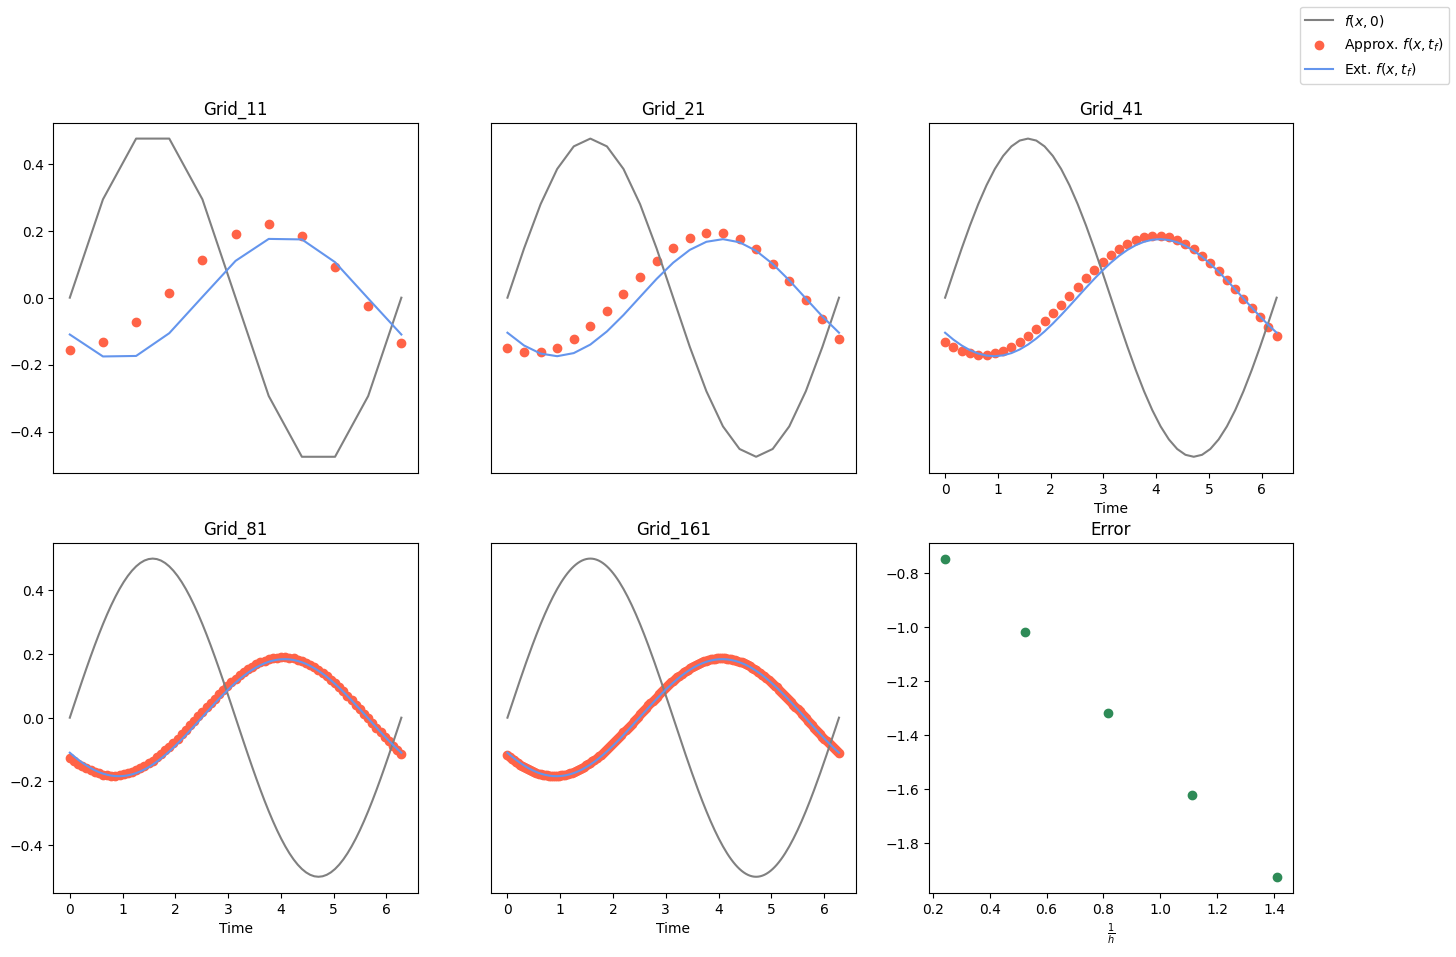

In [18]:
plot_gridRefine(X2,E2,X_ext)

## Fourth Order 

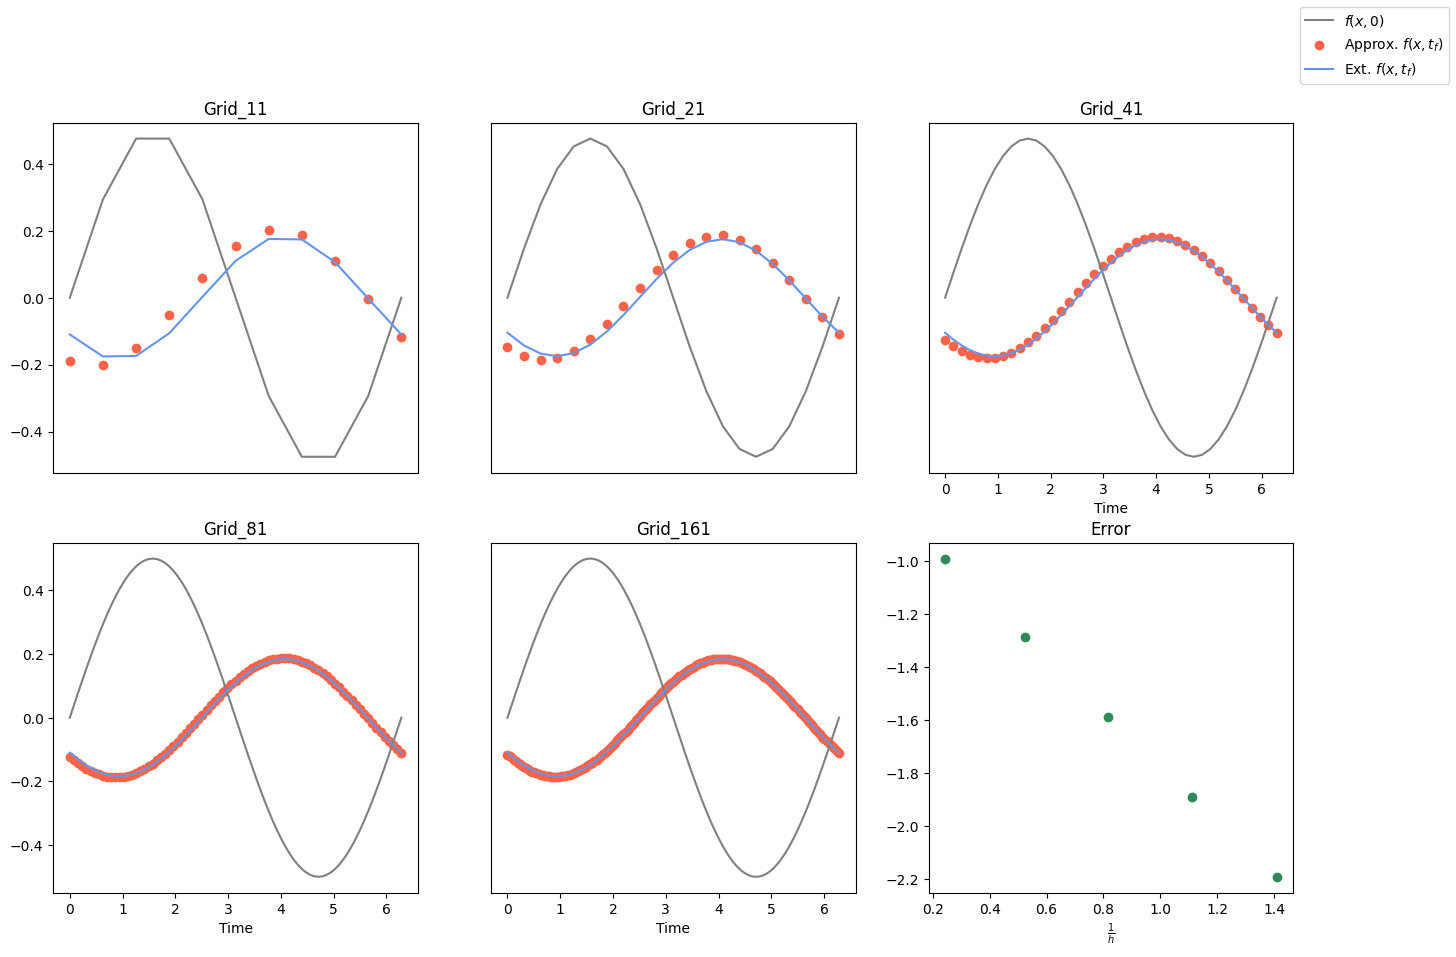

In [19]:
plot_gridRefine(X4,E4,X_ext)

## Error comparison

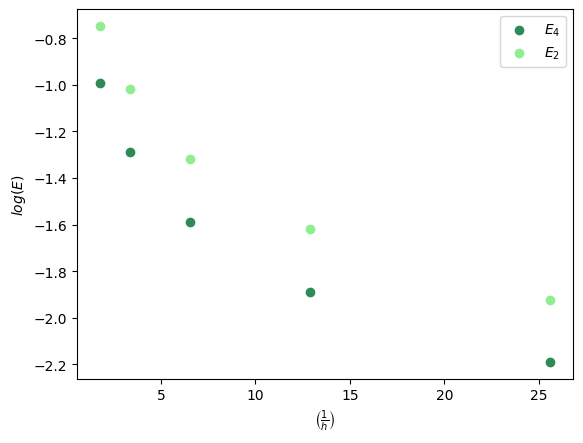

In [20]:
hf = 2*np.pi/np.array(N)

plt.scatter(1/hf,np.log10(E4),color='seagreen',label=r'$E_4$')
plt.scatter(1/hf,np.log10(E2),color='lightgreen',label=r'$E_2$')

plt.xlabel(r'$\left(\frac{1}{h}\right)$')
plt.ylabel(r'$log(E)$')

plt.legend()
plt.show()

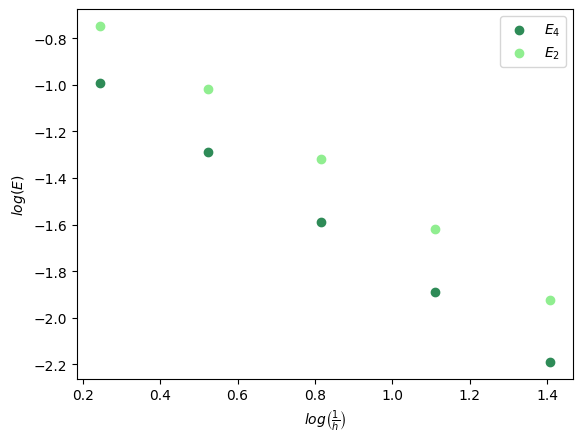

In [21]:
hf = 2*np.pi/np.array(N)

plt.scatter(np.log10(1/hf),np.log10(E4),color='seagreen',label=r'$E_4$')
plt.scatter(np.log10(1/hf),np.log10(E2),color='lightgreen',label=r'$E_2$')

plt.xlabel(r'$log\left(\frac{1}{h}\right)$')
plt.ylabel(r'$log(E)$')

plt.legend()
plt.show()

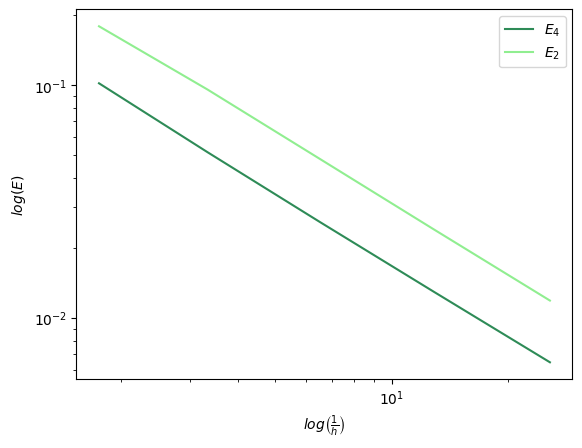

In [22]:
hf = 2*np.pi/np.array(N)

plt.loglog(1/hf,E4,color='seagreen',label=r'$E_4$')
plt.loglog(1/hf,E2,color='lightgreen',label=r'$E_2$')

plt.xlabel(r'$log\left(\frac{1}{h}\right)$')
plt.ylabel(r'$log(E)$')

plt.legend()
plt.show()

I am not quite getting the second part of problem 2. My error is either giving me a completely curved line that can't fit a straight line, or it is giving me an almost perfectly straight line. When I am getting straight lines, the have effectivly the same slope. 

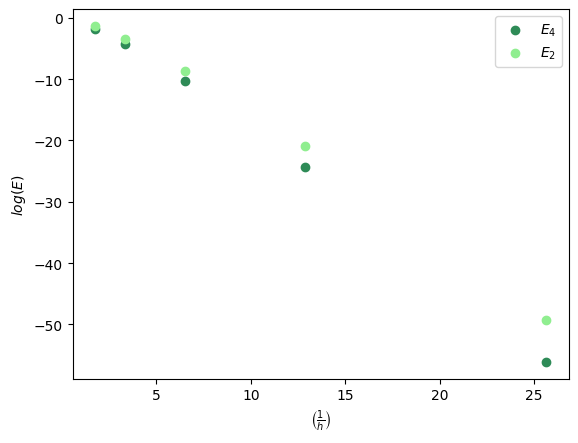

In [23]:
hf = 2*np.pi/np.array(N)

plt.scatter(1/hf,np.log10(E4)/hf,color='seagreen',label=r'$E_4$')
plt.scatter(1/hf,np.log10(E2)/hf,color='lightgreen',label=r'$E_2$')

plt.xlabel(r'$\left(\frac{1}{h}\right)$')
plt.ylabel(r'$log(E)$')

plt.legend()
plt.show()

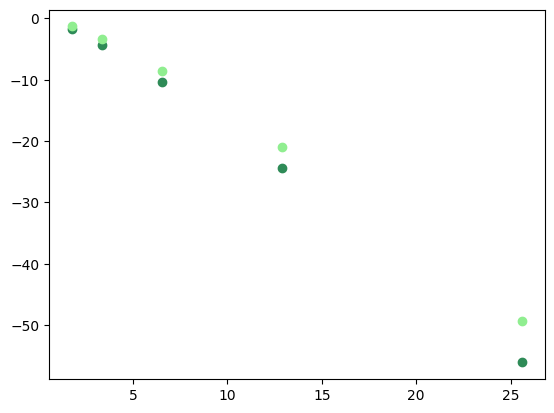

In [24]:
plt.scatter(1/hf,np.log10(E4)/hf,color='seagreen',label=r'$E_4$')
plt.scatter(1/hf,np.log10(E2)/hf,color='lightgreen',label=r'$E_2$')

In [25]:
np.round((np.log10(E2)[-1]/hf[-1]-np.log10(E2)[0]/hf[0])/(1/hf[-1]-1/hf[0]),1)

np.float64(-2.0)

In [26]:
np.round((np.log10(E4)[-1]/hf[-1]-np.log10(E4)[0]/hf[0])/(1/hf[-1]-1/hf[0]),1)

np.float64(-2.3)

## Chopped soln

In [27]:
N = [11,21,41,81,161]
n = N[-1]
dt = 5e-4
nt = 1000 

D = 0.1
u = 0.1

x = np.linspace(0,2*np.pi,n)
h = np.diff(x)[0]

In [28]:
D4 = D4_make(n,h)
L4 = L4_make(n,h)

In [29]:
x0 = np.sin(x)
xi = x0.copy()
xf = np.empty(n)

In [30]:
for i in range(nt):
    xf = dt*(D*L4@xi - u*D4@xi) + xi
    xi = xf

xi = x0.copy()

x_ext = 1*np.exp(-D*1**2*nt*dt)*np.sin(1*(x-u*nt*dt)) #adVec_sin(x,t[-1])

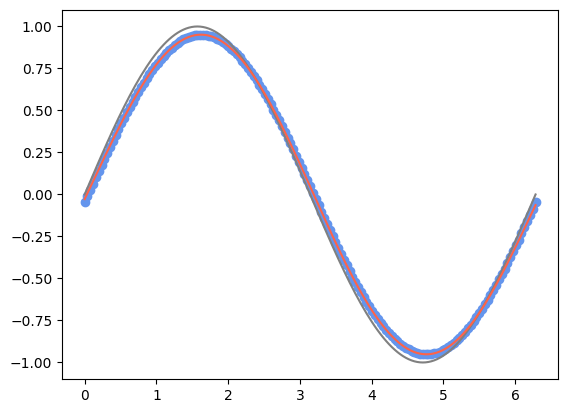

In [31]:
plt.plot(x,x0,color='gray')
plt.plot(x,xf,color='tomato')
plt.scatter(x,x_ext,color='cornflowerblue')
plt.show()